# NEB Viewer for Li2S Migration

This notebook scans all `neb.out` files in this folder's `*_neb_run` subdirectories, extracts the final converged NEB energies, prints a text table per metal, and plots image coordinate (1-5) vs relative energy (eV).

In [1]:
from pathlib import Path
import re
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
OUT_FILES = sorted(BASE_DIR.glob('*_neb_run/neb.out'))

if not OUT_FILES:
    raise FileNotFoundError('No neb.out files were found under *_neb_run/')

print(f'Found {len(OUT_FILES)} NEB output files:')
for f in OUT_FILES:
    print(' -', f)

Found 5 NEB output files:
 - /home/ameer_ubuntu/Git_projects/QE_2/no_u/NEB_Li2S/NbN_neb_run/neb.out
 - /home/ameer_ubuntu/Git_projects/QE_2/no_u/NEB_Li2S/ScN_neb_run/neb.out
 - /home/ameer_ubuntu/Git_projects/QE_2/no_u/NEB_Li2S/TiN_neb_run/neb.out
 - /home/ameer_ubuntu/Git_projects/QE_2/no_u/NEB_Li2S/VN_neb_run/neb.out
 - /home/ameer_ubuntu/Git_projects/QE_2/no_u/NEB_Li2S/ZrN_neb_run/neb.out


In [2]:
BLOCK_PATTERN = re.compile(
    r'activation energy \(->\)\s*=\s*([+-]?\d*\.?\d+)\s*eV\s*'
    r'activation energy \(<-\)\s*=\s*([+-]?\d*\.?\d+)\s*eV\s*'
    r'image\s+energy \(eV\)\s+error \(eV/A\)\s+frozen\s*\n\s*\n'
    r'((?:\s*\d+\s+[+-]?\d*\.?\d+\s+[+-]?\d*\.?\d+\s+[TF]\s*\n)+)',
    re.MULTILINE
)

ROW_PATTERN = re.compile(
    r'^\s*(\d+)\s+([+-]?\d*\.?\d+)\s+([+-]?\d*\.?\d+)\s+([TF])\s*$'
)


def parse_final_neb_block(text):
    matches = list(BLOCK_PATTERN.finditer(text))
    if not matches:
        return None

    # Use the last block because it corresponds to the final NEB iteration.
    m = matches[-1]
    e_forward = float(m.group(1))
    e_backward = float(m.group(2))

    image_indices = []
    image_energies = []
    image_errors = []

    for line in m.group(3).strip().splitlines():
        row = ROW_PATTERN.match(line)
        if not row:
            continue
        image_indices.append(int(row.group(1)))
        image_energies.append(float(row.group(2)))
        image_errors.append(float(row.group(3)))

    if not image_energies:
        return None

    ref = image_energies[0]
    rel_energies = [e - ref for e in image_energies]
    barrier_from_profile = max(rel_energies)

    return {
        'forward_barrier_eV': e_forward,
        'backward_barrier_eV': e_backward,
        'image_indices': image_indices,
        'abs_energies_eV': image_energies,
        'rel_energies_eV': rel_energies,
        'profile_barrier_eV': barrier_from_profile,
        'max_error_eV_per_A': max(image_errors),
    }

In [3]:
records = []
profiles = {}

for out_file in OUT_FILES:
    metal = out_file.parent.stem.replace('_neb_run', '')
    parsed = parse_final_neb_block(out_file.read_text(errors='ignore'))

    if parsed is None:
        records.append({
            'Metal': metal,
            'ForwardBarrier(eV)': None,
            'BackwardBarrier(eV)': None,
            'ProfileMaxDeltaE(eV)': None,
            'Images': None,
            'MaxError(eV/A)': None,
            'Status': 'Could not parse',
        })
        continue

    records.append({
        'Metal': metal,
        'ForwardBarrier(eV)': parsed['forward_barrier_eV'],
        'BackwardBarrier(eV)': parsed['backward_barrier_eV'],
        'ProfileMaxDeltaE(eV)': parsed['profile_barrier_eV'],
        'Images': len(parsed['image_indices']),
        'MaxError(eV/A)': parsed['max_error_eV_per_A'],
        'Status': 'OK',
    })

    profiles[metal] = parsed

records = sorted(records, key=lambda r: r['Metal'])

def format_value(v, width, digits=6):
    if v is None:
        return f"{'-':>{width}}"
    if isinstance(v, (int, float)):
        return f"{v:>{width}.{digits}f}"
    return f"{str(v):>{width}}"

header = (
    f"{'Metal':<8} "
    f"{'Forward(eV)':>12} "
    f"{'Backward(eV)':>13} "
    f"{'Max dE(eV)':>11} "
    f"{'Images':>6} "
    f"{'Max Err':>10} "
    f"{'Status':>10}"
)

print(header)
print('-' * len(header))
for r in records:
    line = (
        f"{r['Metal']:<8} "
        f"{format_value(r['ForwardBarrier(eV)'], 12, 6)} "
        f"{format_value(r['BackwardBarrier(eV)'], 13, 6)} "
        f"{format_value(r['ProfileMaxDeltaE(eV)'], 11, 6)} "
        f"{format_value(r['Images'], 6, 0)} "
        f"{format_value(r['MaxError(eV/A)'], 10, 6)} "
        f"{r['Status']:>10}"
    )
    print(line)

Metal     Forward(eV)  Backward(eV)  Max dE(eV) Images    Max Err     Status
----------------------------------------------------------------------------
NbN          1.168386      0.070655    1.168386      5   0.039725         OK
ScN          1.640920     -0.000000    1.640920      5   0.975097         OK
TiN          1.177080     -0.000000    1.177080      5   0.126588         OK
VN           0.990213      0.000000    0.990213      5   0.106434         OK
ZrN          1.421623      0.268696    1.421623      5   0.045806         OK


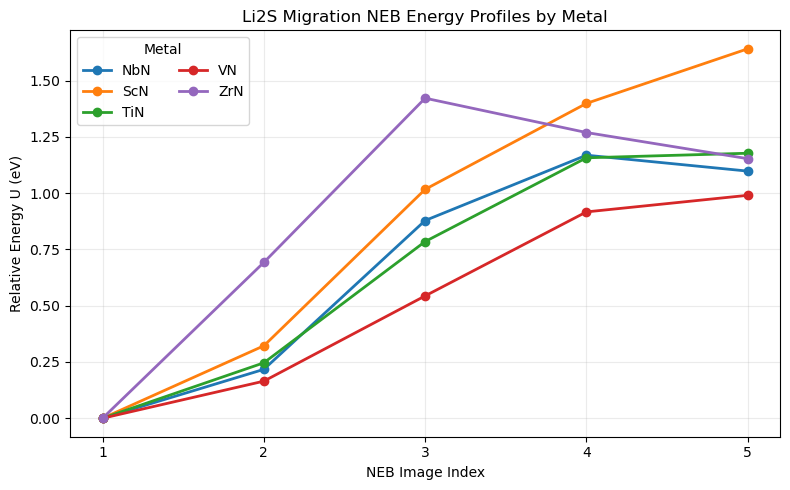

In [4]:
plt.figure(figsize=(8, 5))

for metal in sorted(profiles):
    d = profiles[metal]
    plt.plot(
        d['image_indices'],
        d['rel_energies_eV'],
        marker='o',
        linewidth=2,
        label=metal
    )

plt.xlabel('NEB Image Index')
plt.ylabel('Relative Energy U (eV)')
plt.title('Li2S Migration NEB Energy Profiles by Metal')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(alpha=0.25)
plt.legend(title='Metal', ncol=2)
plt.tight_layout()
plt.show()